# Two-Factor HJM Model for Energy Markets

This notebook presents a study of a two-factor HJM model applied to energy forward prices. The goal is to keep a readable GitHub version, without the full calculation code, but with the figures produced during the project.

The model separates two sources of risk. The first one represents temporary shocks that fade over time. The second one represents more persistent movements in the general price level. This distinction is natural in energy markets, where short-term prices can react strongly to weather, inventories or production constraints, while longer maturities tend to reflect more structural trends.

In [ ]:
from IPython.display import Image, display

## 1. Starting Point of the Model

The log-spot price is written as the sum of two factors:

$$\ln S_t = X_t + Y_t.$$

The factor $X_t$ is mean-reverting. It captures short-term shocks. The factor $Y_t$ is permanent. It shifts the general level of the market.

Under the risk-neutral measure, the dynamics used are:

$$dX_t = \theta(\mu - X_t)dt + \sigma_X dW_t^X,$$

$$dY_t = \sigma_Y dW_t^Y.$$

This specification keeps the model simple to handle while preserving a clear economic interpretation.

## 2. Analytical Forward Price

The first step was to solve the two stochastic differential equations. The factor $X_t$ follows an Ornstein-Uhlenbeck process, while $Y_t$ follows a Brownian dynamics without mean reversion.

Using the conditional expectation of a log-normal variable, we obtain a closed-form expression for the forward price:

$$F_{t,T}=\exp\left(\mu(1-e^{-\theta\tau})+e^{-\theta\tau}X_t+Y_t+\frac{\sigma_X^2}{4\theta}(1-e^{-2\theta\tau})+\frac{\sigma_Y^2\tau}{2}\right),$$

with $\tau=T-t$.

The following figure shows the first numerical check performed in the initial notebook.

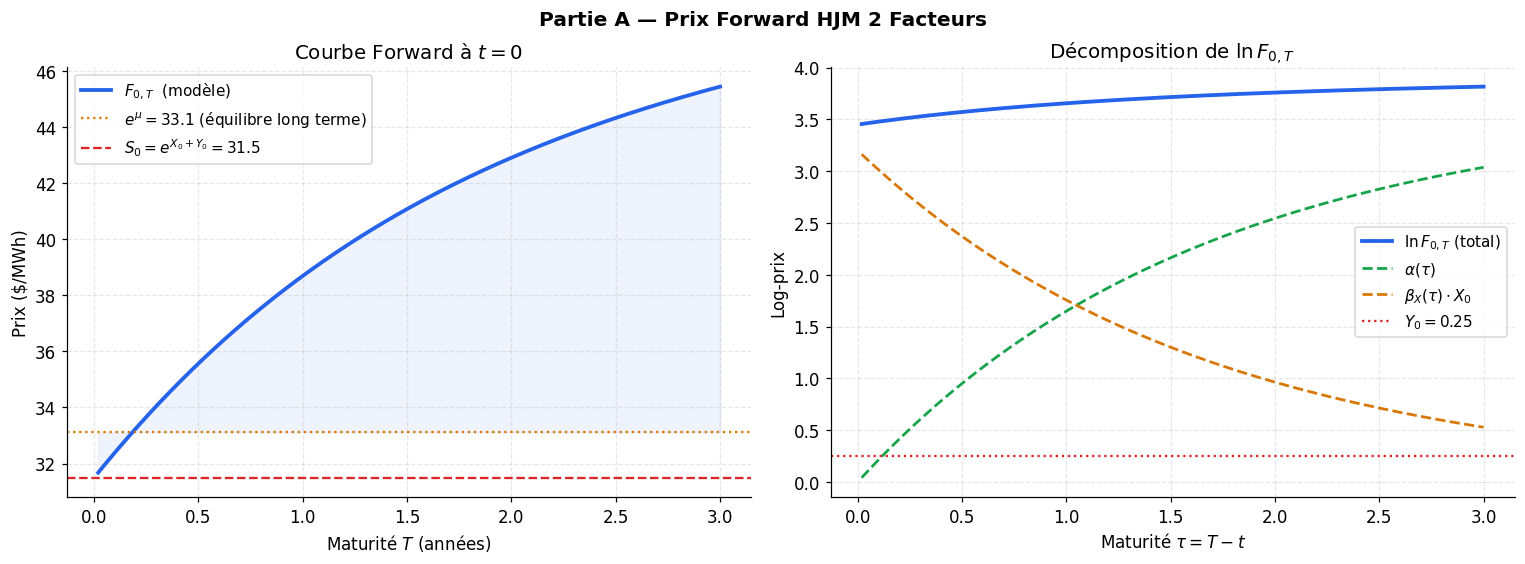

In [ ]:
display(Image(filename="images/01_prix_forward.png"))

## 3. Affine Structure of the Log-Forward Price

The previous result shows that the logarithm of the forward price is affine in $(X_t,Y_t)$:

$$\ln F_{t,T}=\alpha(\tau)+e^{-\theta\tau}X_t+Y_t,$$

where

$$\alpha(\tau)=\mu(1-e^{-\theta\tau})+\frac{\sigma_X^2}{4\theta}(1-e^{-2\theta\tau})+\frac{\sigma_Y^2\tau}{2}.$$

This property is important for calibration. It means that, for fixed volatility parameters, the state variables can be recovered through a linear regression on the futures curve.

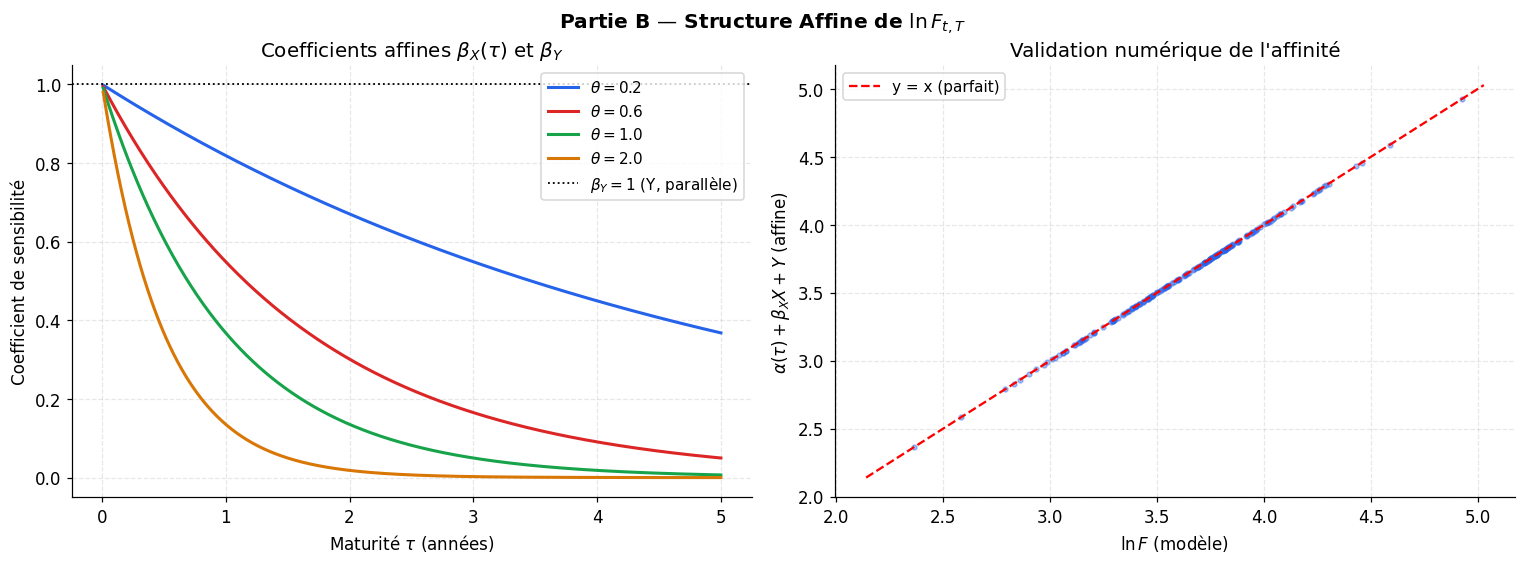

In [ ]:
display(Image(filename="images/02_structure_affine.png"))

## 4. Forward Curve Deformations

The permanent factor $Y_t$ affects all maturities in the same way. It mainly produces a parallel shift of the curve.

The temporary factor $X_t$ mostly affects short maturities, because its coefficient $e^{-\theta(T-t)}$ decreases with maturity. It therefore has a stronger impact on the slope of the curve.

This part of the project helps identify what the model can represent, but also what it cannot represent. With only two factors, the model captures level and slope movements, but not more complex shapes such as a local hump in the middle of the curve.

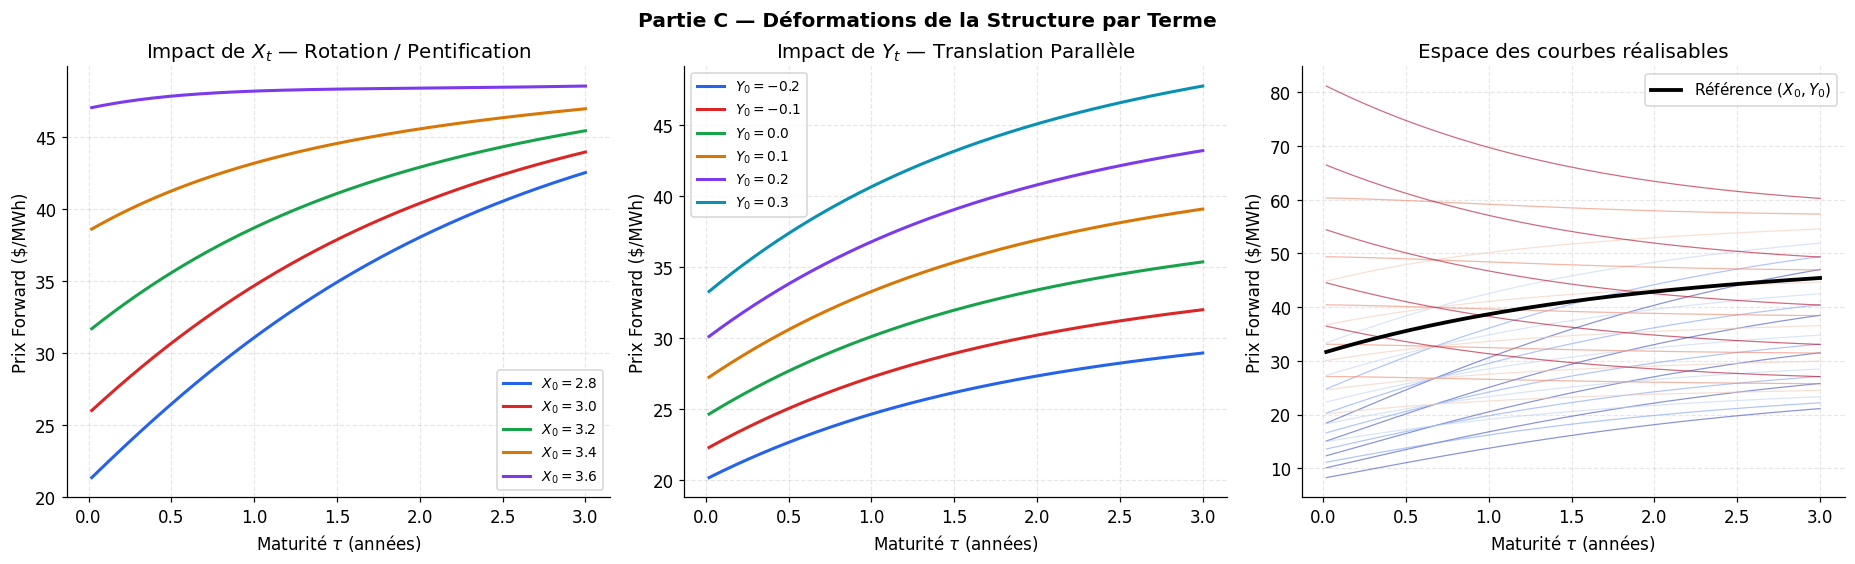

In [ ]:
display(Image(filename="images/03_deformations_courbe_forward.png"))

## 5. Samuelson Effect

The model naturally reproduces the Samuelson effect. The instantaneous volatility of a forward contract with maturity $T$ is:

$$\sigma_{inst}^2(t,T)=\sigma_X^2e^{-2\theta(T-t)}+\sigma_Y^2.$$

As maturity increases, the contribution of the temporary factor decreases. The volatility then converges to the long-term level given by $\sigma_Y$.

This is consistent with the following economic intuition: short-term contracts react more strongly to temporary shocks than long-term contracts.

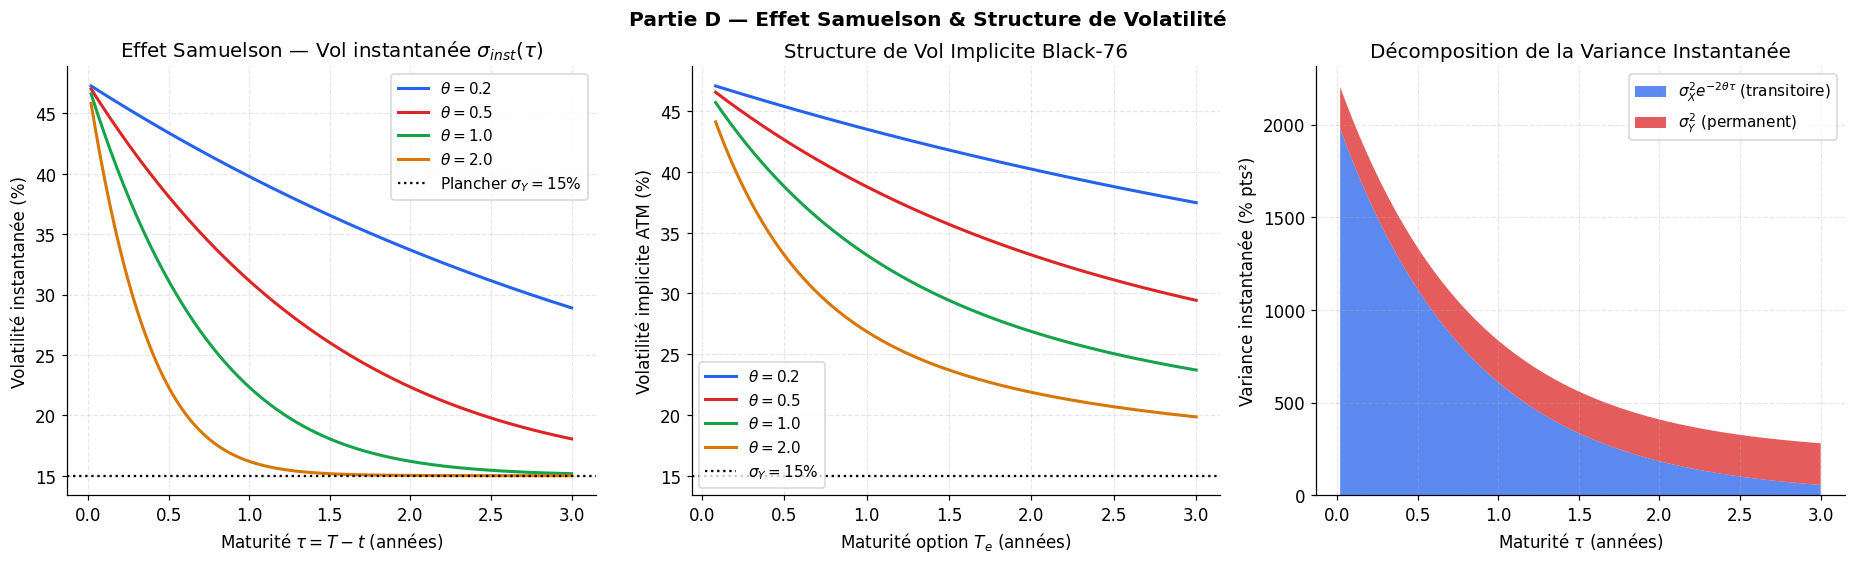

In [ ]:
display(Image(filename="images/04_effet_samuelson.png"))

## 6. Calibration of Volatility Parameters

The calibration was built in two steps.

First, the volatility-related parameters are estimated from ATM implied volatilities. The formula used links the observed Black volatility to the option maturity:

$$\Sigma^2(T_e)=\sigma_Y^2+\frac{\sigma_X^2}{2\theta T_e}(1-e^{-2\theta T_e}).$$

The objective is to recover the parameters $\theta$, $\sigma_X$ and $\sigma_Y$ that best reproduce the observed volatility structure.

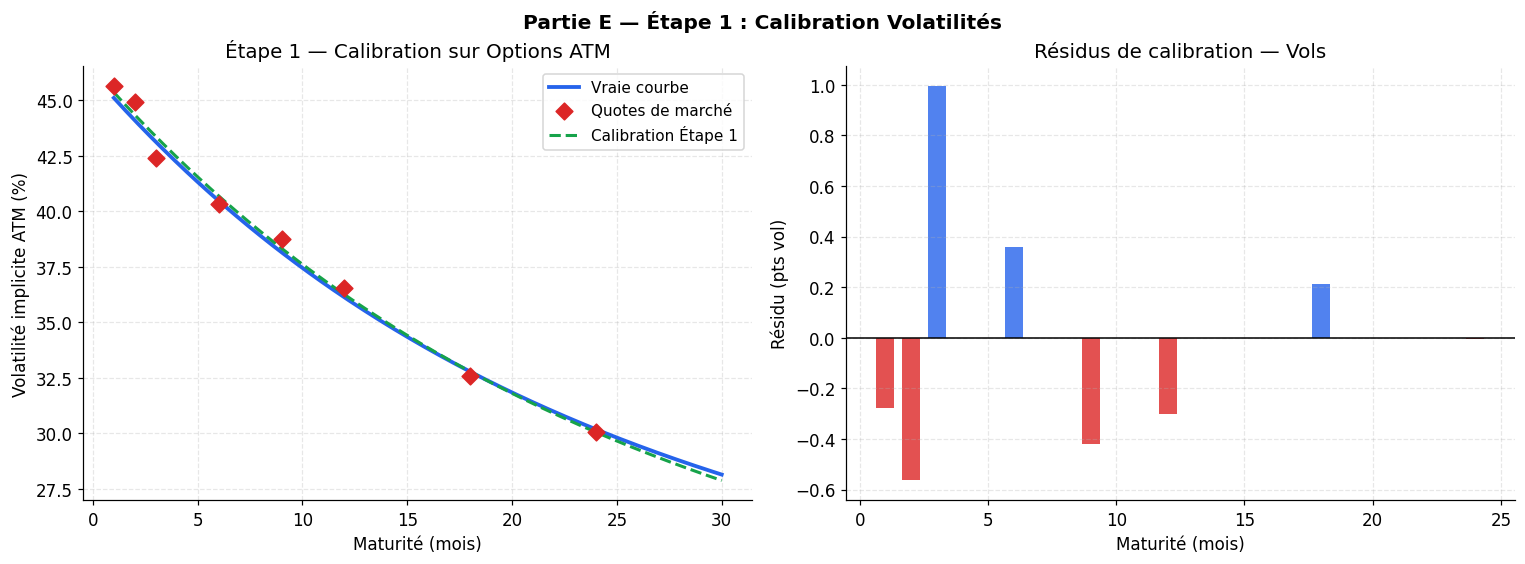

In [ ]:
display(Image(filename="images/05_calibration_volatilite.png"))

## 7. Calibration of the Futures Curve

Once the volatility parameters are fixed, the futures curve is used to estimate the initial state variables. Since the model is affine in $(X_0,Y_0)$, this step reduces to a least-squares problem.

The main advantage of this separation is that it makes the calibration more stable. The dynamic parameters are handled through volatility data, while the current market conditions are adjusted through futures prices.

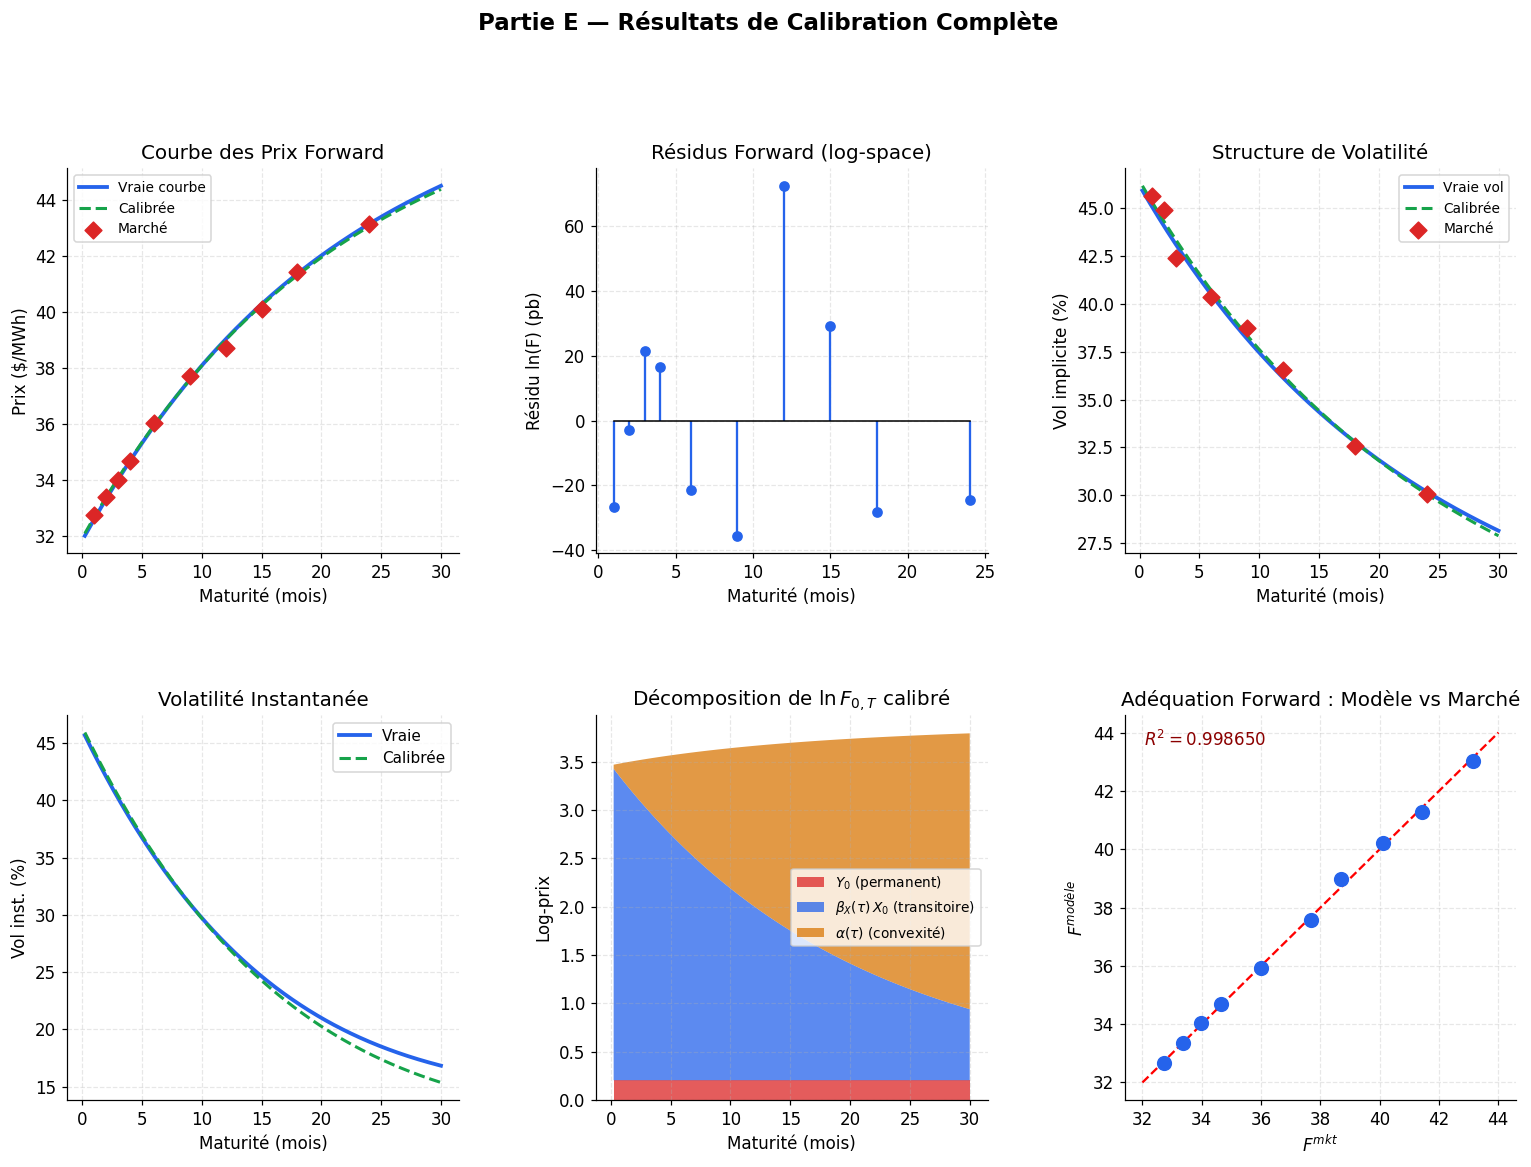

In [ ]:
display(Image(filename="images/06_validation_calibration.png"))

## 8. Monte Carlo Simulation

After calibration, I simulated spot price trajectories. This step is mainly used to check the behavior of the model over time.

The simulated dynamics show pronounced short-term movements driven by the mean-reverting factor, together with a more persistent component linked to the permanent factor.

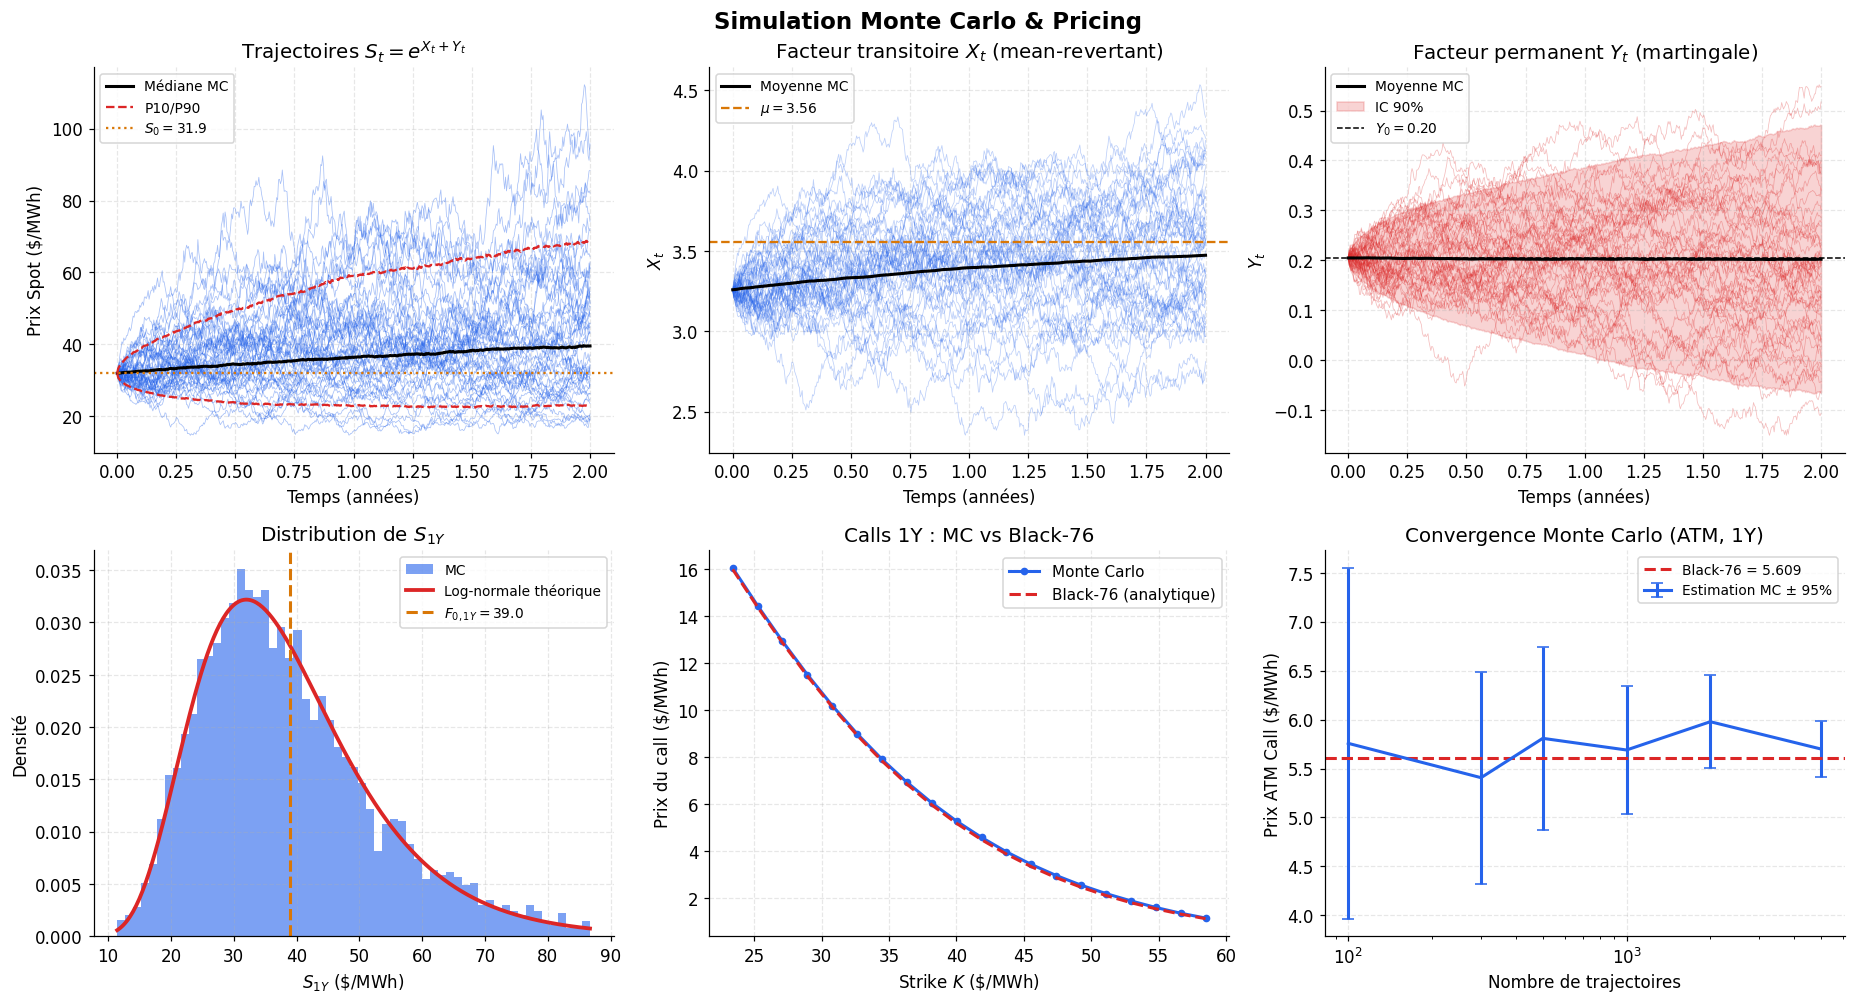

In [ ]:
display(Image(filename="images/07_simulation_monte_carlo.png"))

## 9. Model Sensitivities

The last part of the project studies the sensitivities obtained from the calibrated model. The goal is to understand how prices react to the parameters and to the state variables.

This analysis complements the calibration: the model is not only used to fit a curve, but also to understand the risks carried by the model.

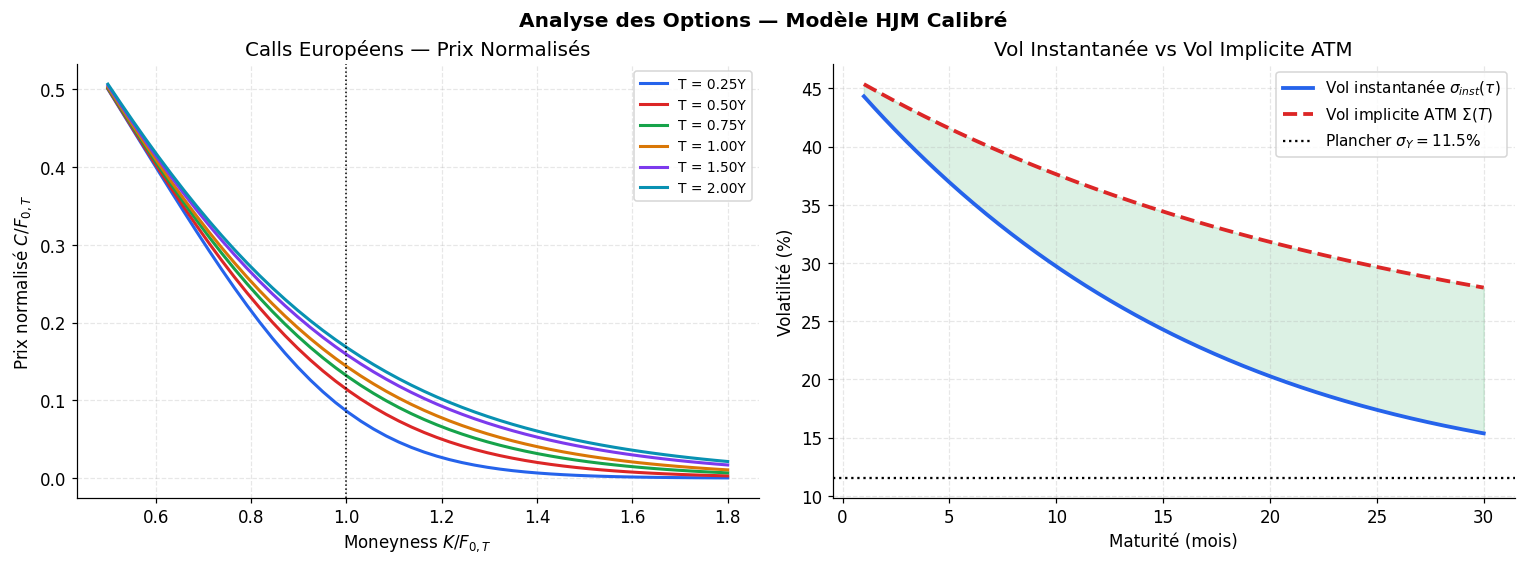

In [ ]:
display(Image(filename="images/08_sensibilites_greeks.png"))

## Conclusion

This project allowed me to build a two-factor HJM model adapted to energy markets, and then use it to analyze a forward curve, calibrate the parameters and simulate the spot price dynamics.

The main strength of the model is its readability. The temporary factor explains short-term movements and the Samuelson effect. The permanent factor explains level shifts of the curve. The affine structure then makes calibration simpler and more robust.

The main limitation comes from the number of factors. The model describes level and slope movements well, but it cannot reproduce every possible shape of a futures curve. To model humps or more local deformations, an additional factor would be needed.